# Retail Stocking Priority Classification: Logistic Regression vs Custom Deep Learning vs Hugging Face

## Project reframing

This notebook reframes the original retail demand forecasting problem into a **multi-class product stocking priority classification** problem.

Instead of asking only:

- *How many units will sell?*

we also ask:

- *Which products or categories deserve higher stocking priority?*
- *Which items are likely to generate better profit relative to shelf space?*
- *Which items should be deprioritized because of short shelf life, low margin, or supply risk?*

This reframing is closer to how retail managers think in practice.

## Modeling goals

We will build and compare three model families:

1. **Logistic Regression** for multi-class classification
2. A **custom deep learning architecture**
3. A **Hugging Face pre-trained transformer** fine-tuned for classification

We will also compare:

- **text-only classification**
- **numeric-only classification**
- **hybrid text + numeric classification**

## Business target

We create a derived target called **Stocking Priority Class** with three classes:

- `Low`
- `Medium`
- `High`

This class is based on a business-oriented score that combines:

- profit density
- sales demand
- shelf life
- fill rate
- supplier delay
- backorder risk

## Important note

The target used in this notebook is **derived from business rules**, not directly provided in the dataset. That means the models are learning to approximate a business prioritization rule, not a historical label already present in the data.

## Mathematical formulation

We define the following intermediate quantities:

### 1. Unit Margin

$$
\text{Unit Margin} = \text{Current Price} - \text{Unit Cost}
$$

### 2. Gross Profit

$$
\text{Gross Profit} = \text{Unit Margin} \times \text{Daily Units Sold}
$$

### 3. Profit Density

$$
\text{Profit Density} = \frac{\text{Gross Profit}}{\text{Shelf Capacity}}
$$

### 4. Stocking Priority Score

After min-max normalization of relevant variables, we define:

$$
\text{Priority Score} =
0.40 \cdot \text{Norm(Profit Density)}
+ 0.20 \cdot \text{Norm(Daily Units Sold)}
+ 0.15 \cdot \text{Norm(Fill Rate)}
+ 0.10 \cdot \text{Norm(Shelf Life)}
+ 0.10 \cdot \left(1 - \text{Norm(Supplier Delay)}\right)
+ 0.05 \cdot \left(1 - \text{Backorder Flag}\right)
$$

Finally, the score is split into three quantile-based classes:

- Low
- Medium
- High

## Colab setup

If you are running this notebook in Google Colab and any of the NLP libraries are missing, uncomment and run the next cell once, then restart the runtime.

In [1]:

# Optional Colab setup cell
# Uncomment only if your environment does not already have these packages.

# !pip install -q transformers datasets accelerate sentencepiece evaluate

In [2]:

# ============================================================
# Imports
# ============================================================

import os
import random
import warnings
import inspect

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
from scipy.special import softmax


## Load the dataset

In [3]:

# ============================================================
# Load dataset
# ============================================================

df = pd.read_csv("/content/master_retail_dataset_v2.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2000, 58)


,Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Category,Base_Price,Discount_Percentage,...,Online_Sales_Units,In_Store_Sales_Units,App_Traffic_Index,Website_Visits,Backorder_Flag,Supplier_Delay_Days,Fill_Rate_Pct,Loyalty_Program_Usage_Count,Repeat_Purchase_Rate,Avg_Basket_Size
0,04/13/2023,3,4,2023,0,0,1002,Grocery,410.09,0.01,...,12,71,488,896,N,0,88.93,11,0.14,3.77
1,12/15/2023,4,12,2023,0,0,1014,Home,89.98,0.30,...,31,71,619,1406,N,2,90.16,31,0.14,1.48
2,09/28/2023,3,9,2023,0,0,1015,Electronics,404.88,0.14,...,32,57,626,1432,N,6,88.00,23,0.38,1.07
3,04/17/2023,0,4,2023,0,0,1012,Grocery,347.97,0.43,...,32,66,626,1432,N,2,91.17,7,0.13,4.67
4,03/13/2023,0,3,2023,0,0,1016,Grocery,280.16,0.14,...,23,77,564,1191,N,0,89.39,9,0.16,2.17


## Inspect columns and data types

In [4]:

# Basic inspection
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)


Columns:
['Date', 'DayOfWeek', 'Month', 'Year', 'Is_Weekend', 'Is_Holiday', 'Product_ID', 'Category', 'Base_Price', 'Discount_Percentage', 'Current_Price', 'Store_ID', 'Store_Type', 'Competitor_Price', 'Footfall_Index', 'Avg_Temperature', 'Rainfall_mm', 'Social_Media_Sentiment', 'Lead_Time_Days', 'Safety_Stock_Level', 'Stock_On_Hand', 'Daily_Units_Sold', 'Festival_Name', 'Festival_Type', 'UPC_EAN', 'Product_Name', 'Sub_Category', 'Brand_Name', 'Brand_Tier', 'Shelf_Life_Days', 'No_of_Checkout_Counters', 'Avg_Billing_Time_min', 'Local_Population_Density', 'Product_Age_Days', 'No_of_Customer_Purchases', 'Unit_Cost', 'Promotional_Campaign_Flag', 'Competitor_Promotion_Flag', 'Google_Trends_Current_Wk', 'Google_Trends_Lag_1w', 'Shelf_Capacity', 'Promotion_Type', 'Marketing_Spend', 'Payday_Flag', 'School_Vacation_Flag', 'Local_Event_Flag', 'Launch_Date', 'Seasonal_Product_Flag', 'Online_Sales_Units', 'In_Store_Sales_Units', 'App_Traffic_Index', 'Website_Visits', 'Backorder_Flag', 'Supplier_D

,0
Date,object
DayOfWeek,int64
Month,int64
Year,int64
Is_Weekend,int64
Is_Holiday,int64
Product_ID,int64
Category,object
Base_Price,float64
Discount_Percentage,float64


## Clean selected flag columns

Some business flags are stored as text. We convert them into numeric 0/1 form where needed.

In [5]:

# ============================================================
# Clean selected binary-like flags
# ============================================================

binary_map = {
    "yes": 1, "y": 1, "true": 1, "1": 1,
    "no": 0, "n": 0, "false": 0, "0": 0
}

for col in ["Backorder_Flag", "Promotional_Campaign_Flag", "Competitor_Promotion_Flag", "Seasonal_Product_Flag"]:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(binary_map)
            .fillna(0)
            .astype(int)
        )

# Convert launch date to datetime
df["Launch_Date"] = pd.to_datetime(df["Launch_Date"], errors="coerce")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

display(df[["Backorder_Flag", "Promotional_Campaign_Flag", "Competitor_Promotion_Flag", "Seasonal_Product_Flag"]].head())

,Backorder_Flag,Promotional_Campaign_Flag,Competitor_Promotion_Flag,Seasonal_Product_Flag
0,0,0,0,1
1,0,1,1,1
2,0,0,1,0
3,0,1,0,0
4,0,0,1,0


## Create the business target: Stocking Priority Class

In [6]:

# ============================================================
# Create business-oriented target
# ============================================================

# 1. Unit margin
df["Unit_Margin"] = df["Current_Price"] - df["Unit_Cost"]

# 2. Gross profit
df["Gross_Profit"] = df["Unit_Margin"] * df["Daily_Units_Sold"]

# 3. Profit density relative to shelf capacity
df["Profit_Density"] = df["Gross_Profit"] / df["Shelf_Capacity"].replace(0, np.nan)
df["Profit_Density"] = df["Profit_Density"].fillna(0)

# Helper function for min-max normalization
def minmax_scale(series):
    series = series.astype(float)
    mn = series.min()
    mx = series.max()
    if mx == mn:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mn) / (mx - mn)

# Normalized components
df["Norm_Profit_Density"] = minmax_scale(df["Profit_Density"])
df["Norm_Daily_Units_Sold"] = minmax_scale(df["Daily_Units_Sold"])
df["Norm_Fill_Rate"] = minmax_scale(df["Fill_Rate_Pct"])
df["Norm_Shelf_Life"] = minmax_scale(df["Shelf_Life_Days"])
df["Norm_Supplier_Delay"] = minmax_scale(df["Supplier_Delay_Days"])

# Business-oriented priority score
df["Stocking_Priority_Score"] = (
    0.40 * df["Norm_Profit_Density"]
    + 0.20 * df["Norm_Daily_Units_Sold"]
    + 0.15 * df["Norm_Fill_Rate"]
    + 0.10 * df["Norm_Shelf_Life"]
    + 0.10 * (1 - df["Norm_Supplier_Delay"])
    + 0.05 * (1 - df["Backorder_Flag"])
)

# Convert score into 3 balanced classes
df["Stocking_Priority_Class"] = pd.qcut(
    df["Stocking_Priority_Score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("Class distribution:")
display(df["Stocking_Priority_Class"].value_counts())

Class distribution:


,count
Stocking_Priority_Class,
Low,667
High,667
Medium,666


## Initial business analysis

The next cells generate actual analysis outputs for:

1. Which categories appear most often in the **High** stocking priority class
2. Which categories have the shortest average shelf life
3. Which products rank highest on the stocking-priority score

In [7]:

# ============================================================
# Category-level analysis
# ============================================================

category_summary = (
    df.groupby("Category")
      .agg(
          Records=("Category", "size"),
          Avg_Daily_Units_Sold=("Daily_Units_Sold", "mean"),
          Avg_Current_Price=("Current_Price", "mean"),
          Avg_Unit_Margin=("Unit_Margin", "mean"),
          Avg_Gross_Profit=("Gross_Profit", "mean"),
          Avg_Shelf_Capacity=("Shelf_Capacity", "mean"),
          Avg_Shelf_Life_Days=("Shelf_Life_Days", "mean")
      )
)

category_high_share = (
    df.assign(Is_High=(df["Stocking_Priority_Class"] == "High").astype(int))
      .groupby("Category")["Is_High"]
      .mean()
      .rename("High_Priority_Share")
)

category_summary = category_summary.join(category_high_share)
category_summary = category_summary.sort_values("High_Priority_Share", ascending=False)

display(category_summary.round(3))

,Records,Avg_Daily_Units_Sold,Avg_Current_Price,Avg_Unit_Margin,Avg_Gross_Profit,Avg_Shelf_Capacity,Avg_Shelf_Life_Days,High_Priority_Share
Category,,,,,,,,
Home,391,111.591,187.388,16.937,1372.081,70.987,2222.056,0.591
Clothing,378,113.257,184.610,16.219,1340.999,69.765,943.532,0.373
Electronics,387,110.687,194.809,18.332,1412.922,73.829,1394.491,0.284
Beauty,402,112.244,182.500,20.036,1690.405,68.888,530.913,0.261
Grocery,442,113.405,180.041,17.507,1577.671,71.068,42.649,0.181


### Interpretation

The table above identifies which categories are more likely to appear in the **High** stocking priority class under the business rule defined in this notebook.

In this dataset, categories such as **Home**, **Clothing**, **Electronics**, and **Beauty** tend to perform better than **Grocery** on the stocking-priority score. Grocery remains important for sales, but its much shorter shelf life can reduce its stocking attractiveness under this business framing.

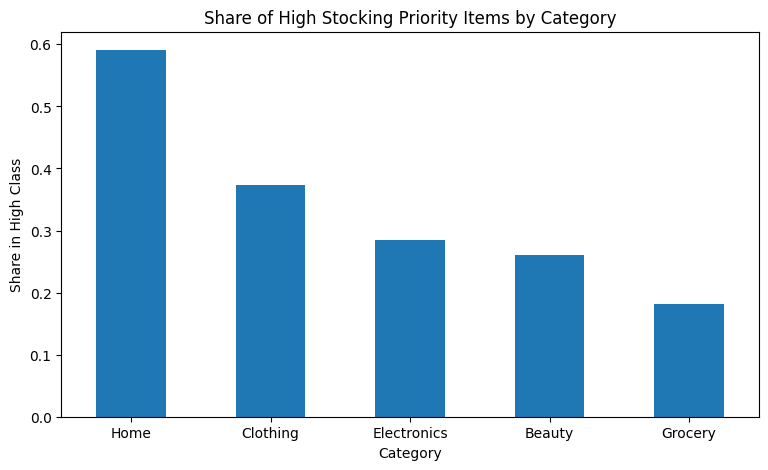

In [8]:

# Plot the share of High priority items by category
high_share_plot = category_summary["High_Priority_Share"].sort_values(ascending=False)

plt.figure(figsize=(9, 5))
high_share_plot.plot(kind="bar")
plt.title("Share of High Stocking Priority Items by Category")
plt.ylabel("Share in High Class")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.show()

,Shelf_Life_Days
Category,
Grocery,42.65
Beauty,530.91
Clothing,943.53
Electronics,1394.49
Home,2222.06


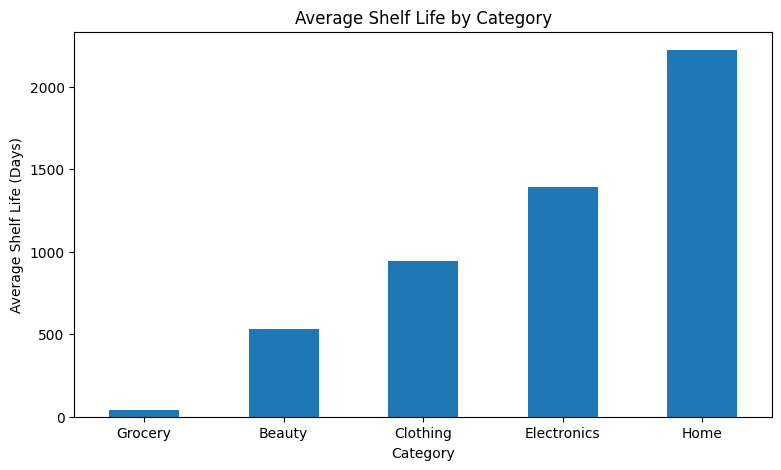

In [9]:

# ============================================================
# Shelf-life analysis
# ============================================================

shelf_life_by_category = (
    df.groupby("Category")["Shelf_Life_Days"]
      .mean()
      .sort_values()
)

display(shelf_life_by_category.round(2))

plt.figure(figsize=(9, 5))
shelf_life_by_category.plot(kind="bar")
plt.title("Average Shelf Life by Category")
plt.ylabel("Average Shelf Life (Days)")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.show()

### Interpretation

Shelf life is central to the instructor's framing.

If a category has short shelf life, heavy stocking can create spoilage risk and reduce business attractiveness even when demand is strong. In this dataset, **Grocery** has by far the shortest average shelf life, which makes it more operationally risky than categories such as **Home** or **Electronics**.

In [10]:

# ============================================================
# Top products by average stocking priority score
# ============================================================

top_products = (
    df.groupby(["Category", "Product_Name"])
      .agg(
          Avg_Priority_Score=("Stocking_Priority_Score", "mean"),
          Avg_Profit_Density=("Profit_Density", "mean"),
          Avg_Shelf_Life=("Shelf_Life_Days", "mean"),
          Records=("Product_Name", "size")
      )
      .sort_values("Avg_Priority_Score", ascending=False)
      .head(15)
)

display(top_products.round(3))

Avg_Priority_Score  Avg_Profit_Density  \
Category Product_Name                                                         
Home     Philips Kitchenware 1004                 0.561              27.981   
         Tupperware Bedding 1001                  0.558              53.273   
         Tupperware Bedding 1017                  0.555              -3.550   
         Sleepwell Furniture 1013                 0.550               8.842   
         Sleepwell Kitchenware 1015               0.549              22.536   
         Ikea Furniture 1018                      0.540              59.867   
         Tupperware Decor 1014                    0.538              32.426   
         Tupperware Decor 1005                    0.537              25.452   
         Tupperware Bedding 1006                  0.536              18.324   
         Ikea Bedding 1008                        0.536              51.706   
         Ikea Kitchenware 1010                    0.533              33.997   
         Tupperware Decor 1003                    0.532              16.206   
         Ikea Kitchenware 1007                    0.528             -14.767   
         Sleepwell Furniture 1000                 0.524              27.497   
Clothing FabIndia Formalwear 1006                 0.524              63.025   

                                     Avg_Shelf_Life  Records  
Category Product_Name                                         
Home     Philips Kitchenware 1004            2366.0       20  
         Tupperware Bedding 1001             2790.0       21  
         Tupperware Bedding 1017             2810.0       19  
         Sleepwell Furniture 1013            2850.0       19  
         Sleepwell Kitchenware 1015          2782.0       19  
         Ikea Furniture 1018                 2770.0       16  
         Tupperware Decor 1014               2244.0       20  
         Tupperware Decor 1005               2280.0       18  
         Tupperware Bedding 1006             2358.0       15  
         Ikea Bedding 1008                   2326.0       11  
         Ikea Kitchenware 1010               2038.0       25  
         Tupperware Decor 1003               2178.0       19  
         Ikea Kitchenware 1007               2470.0       24  
         Sleepwell Furniture 1000            1117.0       11  
Clothing FabIndia Formalwear 1006            1057.0       15

## Build a column-aware text template

Instead of using a raw combined text field, we now build a more meaningful text template that preserves the role of each textual attribute.

### Example template

`Category: Beauty | Product: Lakme Makeup 1009 | Brand: Lakme | Brand Tier: Premium | Promotion: Flash Sale | Festival: Diwali`

This is more informative than simply concatenating tokens without context.

In [11]:

# ============================================================
# Create column-aware text template
# ============================================================

text_columns_for_template = [
    "Category", "Product_Name", "Sub_Category", "Brand_Name",
    "Brand_Tier", "Store_Type", "Promotion_Type", "Festival_Name",
    "Festival_Type"
]

for col in text_columns_for_template:
    df[col] = df[col].fillna("None").astype(str)

df["text_template"] = (
    "Category: " + df["Category"]
    + " | Product: " + df["Product_Name"]
    + " | SubCategory: " + df["Sub_Category"]
    + " | Brand: " + df["Brand_Name"]
    + " | BrandTier: " + df["Brand_Tier"]
    + " | StoreType: " + df["Store_Type"]
    + " | Promotion: " + df["Promotion_Type"]
    + " | FestivalName: " + df["Festival_Name"]
    + " | FestivalType: " + df["Festival_Type"]
)

display(df[["text_template"]].head(3))

,text_template
0,Category: Grocery | Product: Nestle Beverages ...
1,Category: Home | Product: Tupperware Decor 101...
2,Category: Electronics | Product: Sony Computer...


## Define label encoder and train/validation/test splits

We use a **stratified** split so that the class balance is preserved.

This is important because the task is now **multi-class classification**.

In [12]:
# ============================================================
# Encode target labels
# ============================================================

label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["Stocking_Priority_Class"])

# Build Python-native label dictionaries for compatibility with
# Hugging Face model configuration (JSON serializable keys/values).
class_names = [str(x) for x in label_encoder.classes_]
label_mapping = {str(label): int(i) for i, label in enumerate(class_names)}
inverse_label_mapping = {int(i): str(label) for i, label in enumerate(class_names)}

print("Label mapping:", label_mapping)
print("Inverse label mapping:", inverse_label_mapping)

Label mapping: {'High': 0, 'Low': 1, 'Medium': 2}
Inverse label mapping: {0: 'High', 1: 'Low', 2: 'Medium'}


In [13]:

# ============================================================
# Train / validation / test split
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_id"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain class distribution:")
display(train_df["Stocking_Priority_Class"].value_counts(normalize=True).round(3))

print("\nValidation class distribution:")
display(val_df["Stocking_Priority_Class"].value_counts(normalize=True).round(3))

print("\nTest class distribution:")
display(test_df["Stocking_Priority_Class"].value_counts(normalize=True).round(3))

Train shape: (1400, 70)
Validation shape: (300, 70)
Test shape: (300, 70)

Train class distribution:


,proportion
Stocking_Priority_Class,
Low,0.334
High,0.334
Medium,0.333



Validation class distribution:


,proportion
Stocking_Priority_Class,
Low,0.333
Medium,0.333
High,0.333



Test class distribution:


,proportion
Stocking_Priority_Class,
Low,0.333
Medium,0.333
High,0.333


## Prepare numeric features

To avoid trivial leakage, we **exclude** the exact variables used to construct the target score whenever possible.

We keep context-rich numeric variables such as:
- traffic
- seasonality proxies
- marketing
- store operations
- trends
- customer behavior

In [14]:

# ============================================================
# Numeric feature selection
# ============================================================

numeric_feature_cols = [
    "DayOfWeek",
    "Month",
    "Year",
    "Is_Weekend",
    "Is_Holiday",
    "Base_Price",
    "Discount_Percentage",
    "Competitor_Price",
    "Footfall_Index",
    "Avg_Temperature",
    "Rainfall_mm",
    "Lead_Time_Days",
    "Safety_Stock_Level",
    "Stock_On_Hand",
    "No_of_Checkout_Counters",
    "Avg_Billing_Time_min",
    "Local_Population_Density",
    "Product_Age_Days",
    "No_of_Customer_Purchases",
    "Promotional_Campaign_Flag",
    "Competitor_Promotion_Flag",
    "Google_Trends_Current_Wk",
    "Google_Trends_Lag_1w",
    "Marketing_Spend",
    "Payday_Flag",
    "School_Vacation_Flag",
    "Local_Event_Flag",
    "Seasonal_Product_Flag",
    "App_Traffic_Index",
    "Website_Visits",
    "Loyalty_Program_Usage_Count",
    "Repeat_Purchase_Rate",
    "Avg_Basket_Size"
]

# Ensure the selected columns exist
numeric_feature_cols = [col for col in numeric_feature_cols if col in df.columns]

print("Numeric features used:", len(numeric_feature_cols))
print(numeric_feature_cols)

Numeric features used: 33
['DayOfWeek', 'Month', 'Year', 'Is_Weekend', 'Is_Holiday', 'Base_Price', 'Discount_Percentage', 'Competitor_Price', 'Footfall_Index', 'Avg_Temperature', 'Rainfall_mm', 'Lead_Time_Days', 'Safety_Stock_Level', 'Stock_On_Hand', 'No_of_Checkout_Counters', 'Avg_Billing_Time_min', 'Local_Population_Density', 'Product_Age_Days', 'No_of_Customer_Purchases', 'Promotional_Campaign_Flag', 'Competitor_Promotion_Flag', 'Google_Trends_Current_Wk', 'Google_Trends_Lag_1w', 'Marketing_Spend', 'Payday_Flag', 'School_Vacation_Flag', 'Local_Event_Flag', 'Seasonal_Product_Flag', 'App_Traffic_Index', 'Website_Visits', 'Loyalty_Program_Usage_Count', 'Repeat_Purchase_Rate', 'Avg_Basket_Size']


# 1. Logistic Regression Baselines

We compare three variants:

1. **Text-only logistic regression**
2. **Numeric-only logistic regression**
3. **Hybrid logistic regression (text + numeric)**

This helps us understand whether the business signal is coming more from category/product text, structured numeric context, or both together.

In [15]:

# ============================================================
# Helper functions for evaluation
# ============================================================

def evaluate_predictions(y_true, y_pred, model_name):
    """
    Return a dictionary with common multi-class classification metrics.
    """
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted")
    }

def print_report(y_true, y_pred, title):
    print(f"\n{title}")
    print("=" * len(title))
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

In [16]:

# ============================================================
# Text-only logistic regression
# ============================================================

text_only_clf = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED))
])

text_only_clf.fit(train_df["text_template"], train_df["label_id"])
text_only_pred = text_only_clf.predict(test_df["text_template"])

text_only_metrics = evaluate_predictions(test_df["label_id"], text_only_pred, "LogReg_TextOnly")
print_report(test_df["label_id"], text_only_pred, "Text-only Logistic Regression Report")
text_only_metrics


Text-only Logistic Regression Report
              precision    recall  f1-score   support

        High       0.52      0.49      0.50       100
         Low       0.42      0.56      0.48       100
      Medium       0.36      0.26      0.30       100

    accuracy                           0.44       300
   macro avg       0.43      0.44      0.43       300
weighted avg       0.43      0.44      0.43       300



{'Model': 'LogReg_TextOnly',
 'Accuracy': 0.43666666666666665,
 'Macro_F1': 0.4285254597461405,
 'Weighted_F1': 0.4285254597461404}

In [17]:

# ============================================================
# Numeric-only logistic regression
# ============================================================

numeric_only_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_only_X_train = numeric_only_preprocessor.fit_transform(train_df[numeric_feature_cols])
numeric_only_X_test = numeric_only_preprocessor.transform(test_df[numeric_feature_cols])

numeric_only_clf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=SEED
)

numeric_only_clf.fit(numeric_only_X_train, train_df["label_id"])
numeric_only_pred = numeric_only_clf.predict(numeric_only_X_test)

numeric_only_metrics = evaluate_predictions(test_df["label_id"], numeric_only_pred, "LogReg_NumericOnly")
print_report(test_df["label_id"], numeric_only_pred, "Numeric-only Logistic Regression Report")
numeric_only_metrics


Numeric-only Logistic Regression Report
              precision    recall  f1-score   support

        High       0.44      0.51      0.47       100
         Low       0.45      0.56      0.50       100
      Medium       0.35      0.21      0.26       100

    accuracy                           0.43       300
   macro avg       0.41      0.43      0.41       300
weighted avg       0.41      0.43      0.41       300



{'Model': 'LogReg_NumericOnly',
 'Accuracy': 0.4266666666666667,
 'Macro_F1': 0.4115740740740741,
 'Weighted_F1': 0.4115740740740741}

In [18]:

# ============================================================
# Hybrid logistic regression (text + numeric)
# ============================================================

hybrid_preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=5000, ngram_range=(1, 2)), "text_template"),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_feature_cols)
])

hybrid_clf = Pipeline([
    ("preprocessor", hybrid_preprocessor),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED))
])

hybrid_clf.fit(train_df[["text_template"] + numeric_feature_cols], train_df["label_id"])
hybrid_pred = hybrid_clf.predict(test_df[["text_template"] + numeric_feature_cols])

hybrid_metrics = evaluate_predictions(test_df["label_id"], hybrid_pred, "LogReg_Hybrid")
print_report(test_df["label_id"], hybrid_pred, "Hybrid Logistic Regression Report")
hybrid_metrics


Hybrid Logistic Regression Report
              precision    recall  f1-score   support

        High       0.50      0.55      0.53       100
         Low       0.54      0.58      0.56       100
      Medium       0.35      0.29      0.32       100

    accuracy                           0.47       300
   macro avg       0.46      0.47      0.47       300
weighted avg       0.46      0.47      0.47       300



{'Model': 'LogReg_Hybrid',
 'Accuracy': 0.47333333333333333,
 'Macro_F1': 0.4669826626254581,
 'Weighted_F1': 0.4669826626254581}

In [19]:

# Logistic regression comparison table
logreg_results = pd.DataFrame([
    text_only_metrics,
    numeric_only_metrics,
    hybrid_metrics
]).sort_values(["Weighted_F1", "Accuracy"], ascending=False)

display(logreg_results.round(4))

,Model,Accuracy,Macro_F1,Weighted_F1
2,LogReg_Hybrid,0.4733,0.4670,0.4670
0,LogReg_TextOnly,0.4367,0.4285,0.4285
1,LogReg_NumericOnly,0.4267,0.4116,0.4116


### Interpretation

The logistic regression comparison tells us whether:
- product/category text alone is enough
- numeric context alone is enough
- or the **hybrid view** is strongest

In many retail problems, the hybrid setup performs best because it combines:
- semantic category/product information
- structured operational context

# 2. Custom Deep Learning Architecture

We build a custom **hybrid neural network** with:

- a **text branch** that learns from the column-aware text template
- a **numeric branch** that learns from structured numeric features

The two branches are merged before the final softmax classification layer.

In [20]:

# ============================================================
# TensorFlow / Keras imports
# ============================================================

import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    TextVectorization,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(SEED)

In [21]:

# ============================================================
# Prepare data for the custom hybrid model
# ============================================================

# Text arrays
X_train_text = train_df["text_template"].astype(str).values
X_val_text = val_df["text_template"].astype(str).values
X_test_text = test_df["text_template"].astype(str).values

# Numeric arrays
numeric_imputer = SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()

X_train_num = numeric_imputer.fit_transform(train_df[numeric_feature_cols])
X_val_num = numeric_imputer.transform(val_df[numeric_feature_cols])
X_test_num = numeric_imputer.transform(test_df[numeric_feature_cols])

X_train_num = numeric_scaler.fit_transform(X_train_num)
X_val_num = numeric_scaler.transform(X_val_num)
X_test_num = numeric_scaler.transform(X_test_num)

# Labels
y_train = train_df["label_id"].values
y_val = val_df["label_id"].values
y_test = test_df["label_id"].values

print("Text training shape:", X_train_text.shape)
print("Numeric training shape:", X_train_num.shape)

Text training shape: (1400,)
Numeric training shape: (1400, 33)


In [22]:

# ============================================================
# Text vectorization layer
# ============================================================

max_tokens = 8000
sequence_length = 40

text_vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

# Adapt vectorizer only on training text
text_vectorizer.adapt(X_train_text)

In [23]:

# ============================================================
# Build custom hybrid neural network
# ============================================================

# Text input branch
text_input = Input(shape=(1,), dtype=tf.string, name="text_input")
x_text = text_vectorizer(text_input)
x_text = Embedding(input_dim=max_tokens, output_dim=64)(x_text)
x_text = Bidirectional(LSTM(32))(x_text)
x_text = Dense(32, activation="relu")(x_text)
x_text = Dropout(0.3)(x_text)

# Numeric input branch
num_input = Input(shape=(X_train_num.shape[1],), name="numeric_input")
x_num = Dense(64, activation="relu")(num_input)
x_num = Dropout(0.3)(x_num)
x_num = Dense(32, activation="relu")(x_num)

# Merge both branches
x = Concatenate()([x_text, x_num])
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(len(label_encoder.classes_), activation="softmax")(x)

custom_model = Model(inputs=[text_input, num_input], outputs=output)

custom_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

custom_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 40)        │          0 │ text_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 64)    │    512,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64)        │     24,832 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      2,176 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 547,523 (2.09 MB)

 Trainable params: 547,523 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:

# ============================================================
# Train custom hybrid neural network
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = custom_model.fit(
    {"text_input": X_train_text, "numeric_input": X_train_num},
    y_train,
    validation_data=(
        {"text_input": X_val_text, "numeric_input": X_val_num},
        y_val
    ),
    epochs=8,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - accuracy: 0.3557 - loss: 1.1380 - val_accuracy: 0.4200 - val_loss: 1.0824
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.4279 - loss: 1.0575 - val_accuracy: 0.4333 - val_loss: 1.0395
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.4443 - loss: 1.0251 - val_accuracy: 0.4567 - val_loss: 1.0256
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.4914 - loss: 0.9849 - val_accuracy: 0.4200 - val_loss: 1.0244
Epoch 5/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.4971 - loss: 0.9723 - val_accuracy: 0.4067 - val_loss: 1.0272
Epoch 6/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.5079 - loss: 0.9705 - val_accuracy: 0.4267 - val_loss: 1.0235
Epoch 7/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5336 - loss: 0.9492 - val_accuracy: 0.4300 - val_loss: 1.0261
Epoch 8/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.5293 - loss: 0.9379 - val_accuracy: 0.3900 - val_lo

In [25]:

# ============================================================
# Evaluate custom hybrid neural network
# ============================================================

custom_pred_probs = custom_model.predict(
    {"text_input": X_test_text, "numeric_input": X_test_num},
    verbose=0
)

custom_pred = np.argmax(custom_pred_probs, axis=1)

custom_metrics = evaluate_predictions(y_test, custom_pred, "CustomDL_Hybrid")
print_report(y_test, custom_pred, "Custom Deep Learning Hybrid Model Report")
custom_metrics


Custom Deep Learning Hybrid Model Report
              precision    recall  f1-score   support

        High       0.52      0.62      0.57       100
         Low       0.47      0.63      0.54       100
      Medium       0.43      0.20      0.27       100

    accuracy                           0.48       300
   macro avg       0.47      0.48      0.46       300
weighted avg       0.47      0.48      0.46       300



{'Model': 'CustomDL_Hybrid',
 'Accuracy': 0.48333333333333334,
 'Macro_F1': 0.45892680922035134,
 'Weighted_F1': 0.4589268092203513}

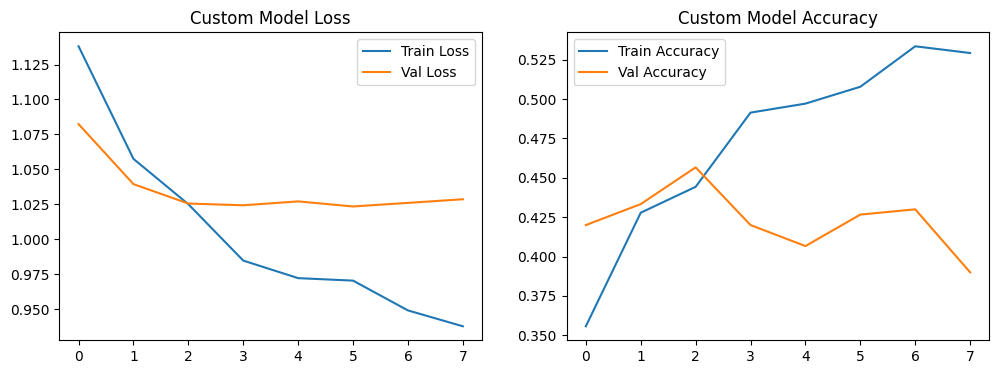

In [26]:

# Plot training curves
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["loss"], label="Train Loss")
axes[0].plot(history_df["val_loss"], label="Val Loss")
axes[0].set_title("Custom Model Loss")
axes[0].legend()

axes[1].plot(history_df["accuracy"], label="Train Accuracy")
axes[1].plot(history_df["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Custom Model Accuracy")
axes[1].legend()

plt.show()

# 3. Hugging Face Pre-trained Transformer

For the Hugging Face baseline, we fine-tune a pre-trained text classification model on the **column-aware text template**.

To keep training practical in Colab, we use a compact transformer such as:

- `distilbert-base-uncased`

This model is **text-only**, so it does not use the numeric feature block.

In [27]:

# ============================================================
# Hugging Face imports
# ============================================================

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

In [28]:

# ============================================================
# Prepare Hugging Face datasets
# ============================================================

hf_train_df = train_df[["text_template", "label_id"]].rename(columns={"text_template": "text", "label_id": "label"})
hf_val_df = val_df[["text_template", "label_id"]].rename(columns={"text_template": "text", "label_id": "label"})
hf_test_df = test_df[["text_template", "label_id"]].rename(columns={"text_template": "text", "label_id": "label"})

hf_train = Dataset.from_pandas(hf_train_df.reset_index(drop=True))
hf_val = Dataset.from_pandas(hf_val_df.reset_index(drop=True))
hf_test = Dataset.from_pandas(hf_test_df.reset_index(drop=True))

In [29]:

# ============================================================
# Tokenizer and tokenization
# ============================================================

checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True)

tokenized_train = hf_train.map(tokenize_batch, batched=True)
tokenized_val = hf_val.map(tokenize_batch, batched=True)
tokenized_test = hf_test.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [30]:
# ============================================================
# Load pre-trained model
# ============================================================

hf_model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(class_names),
    id2label=inverse_label_mapping,
    label2id=label_mapping
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:

# ============================================================
# Metrics for Hugging Face Trainer
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }

In [32]:
# ============================================================
# Training arguments
# ============================================================

# Transformers API differs across versions. This block detects which
# arguments are supported and builds a compatible TrainingArguments object.
training_kwargs = {
    "output_dir": "hf_stocking_priority_results",
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "num_train_epochs": 2,
    "weight_decay": 0.01,
    "report_to": "none",
    "seed": SEED
}

supported_args = set(inspect.signature(TrainingArguments.__init__).parameters.keys())

if "evaluation_strategy" in supported_args:
    training_kwargs["evaluation_strategy"] = "epoch"
if "save_strategy" in supported_args:
    training_kwargs["save_strategy"] = "no"
elif "save_steps" in supported_args:
    training_kwargs["save_steps"] = 10_000

if "logging_strategy" in supported_args:
    training_kwargs["logging_strategy"] = "epoch"
elif "logging_steps" in supported_args:
    training_kwargs["logging_steps"] = 100

# Older Transformers versions use do_train / do_eval flags.
if "do_train" in supported_args:
    training_kwargs["do_train"] = True
if "do_eval" in supported_args:
    training_kwargs["do_eval"] = True

training_args = TrainingArguments(**training_kwargs)
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=True,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.NO,
eval_use_gather_object=False,
f

In [33]:
# ============================================================
# Trainer
# ============================================================

# Note:
# - tokenized_train / tokenized_val are already tokenized
# - data_collator handles padding
# - some Transformers versions do not accept tokenizer= in Trainer

trainer = Trainer(
    model=hf_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [34]:
# ============================================================
# Train Hugging Face model
# ============================================================

trainer.train()

# Explicit evaluation is more version-robust than relying only on
# evaluation_strategy.
trainer.evaluate()

Step,Training Loss
88,1.089214
176,1.040575


{'eval_loss': 1.0635212659835815,
 'eval_accuracy': 0.43,
 'eval_macro_f1': 0.4005270092226614,
 'eval_weighted_f1': 0.4005270092226614,
 'eval_runtime': 24.121,
 'eval_samples_per_second': 12.437,
 'eval_steps_per_second': 0.788,
 'epoch': 2.0}

In [35]:

# ============================================================
# Evaluate Hugging Face model on test data
# ============================================================

hf_test_pred = trainer.predict(tokenized_test)
hf_preds = np.argmax(hf_test_pred.predictions, axis=1)

hf_metrics = evaluate_predictions(hf_test_df["label"].values, hf_preds, "HF_DistilBERT_TextOnly")
print_report(hf_test_df["label"].values, hf_preds, "Hugging Face DistilBERT Report")
hf_metrics


Hugging Face DistilBERT Report
              precision    recall  f1-score   support

        High       0.54      0.57      0.55       100
         Low       0.39      0.68      0.50       100
      Medium       0.15      0.03      0.05       100

    accuracy                           0.43       300
   macro avg       0.36      0.43      0.37       300
weighted avg       0.36      0.43      0.37       300



{'Model': 'HF_DistilBERT_TextOnly',
 'Accuracy': 0.4266666666666667,
 'Macro_F1': 0.36658280773864366,
 'Weighted_F1': 0.3665828077386436}

# Final comparison: Logistic Regression vs Custom DL vs Hugging Face

In [36]:

# ============================================================
# Combine all model results
# ============================================================

final_results = pd.DataFrame([
    text_only_metrics,
    numeric_only_metrics,
    hybrid_metrics,
    custom_metrics,
    hf_metrics
]).sort_values(["Weighted_F1", "Accuracy"], ascending=False)

display(final_results.round(4))

,Model,Accuracy,Macro_F1,Weighted_F1
2,LogReg_Hybrid,0.4733,0.4670,0.4670
3,CustomDL_Hybrid,0.4833,0.4589,0.4589
0,LogReg_TextOnly,0.4367,0.4285,0.4285
1,LogReg_NumericOnly,0.4267,0.4116,0.4116
4,HF_DistilBERT_TextOnly,0.4267,0.3666,0.3666


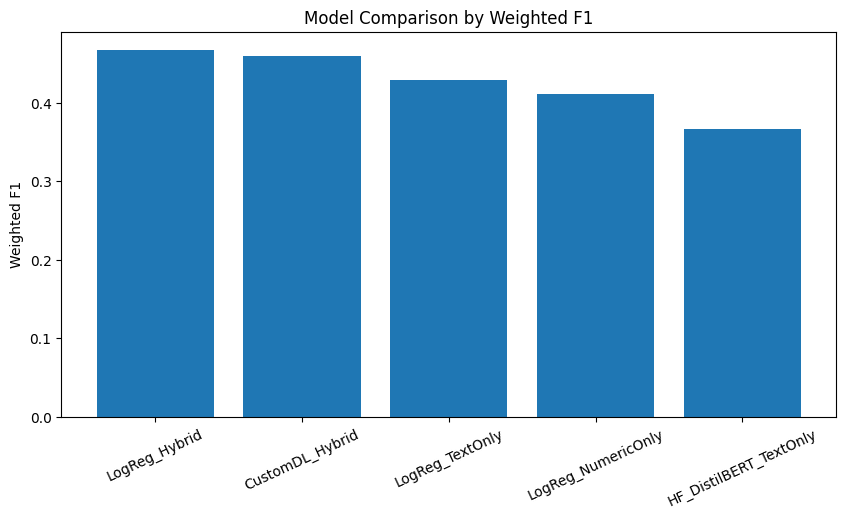

In [37]:

# Plot weighted F1 comparison
plot_df = final_results.sort_values("Weighted_F1", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["Weighted_F1"])
plt.title("Model Comparison by Weighted F1")
plt.ylabel("Weighted F1")
plt.xticks(rotation=25)
plt.show()

## Interpretation of the comparison

This comparison answers two different questions:

### A. Representation question
Which input representation works best?
- text-only
- numeric-only
- hybrid

### B. Model family question
Which model family works best?
- Logistic Regression
- Custom Deep Learning
- Hugging Face Transformer

A common pattern is:

- **Hybrid models** outperform text-only or numeric-only baselines
- **Logistic Regression** is a strong interpretable baseline
- **Custom deep learning** can capture richer nonlinear interactions
- **Hugging Face** can work well when the text template contains enough business meaning

## Analyze which categories appear most often in the High class

Counts of categories in High class:


,count
Category,
Home,231
Clothing,141
Electronics,110
Beauty,105
Grocery,80


Share of categories in High class:


,proportion
Category,
Home,0.3463
Clothing,0.2114
Electronics,0.1649
Beauty,0.1574
Grocery,0.1199


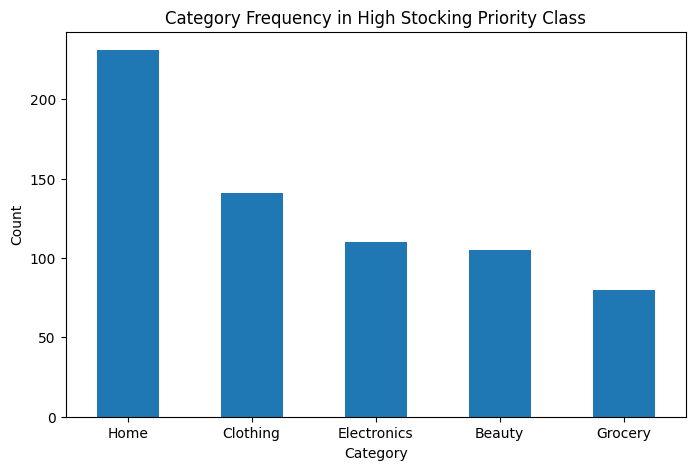

In [38]:

# ============================================================
# Category frequency within High stocking priority class
# ============================================================

high_class_df = df[df["Stocking_Priority_Class"] == "High"]

high_category_counts = high_class_df["Category"].value_counts()
high_category_share = high_class_df["Category"].value_counts(normalize=True)

print("Counts of categories in High class:")
display(high_category_counts)

print("Share of categories in High class:")
display(high_category_share.round(4))

plt.figure(figsize=(8, 5))
high_category_counts.plot(kind="bar")
plt.title("Category Frequency in High Stocking Priority Class")
plt.ylabel("Count")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.show()

## Shelf-life-aware analysis

To reflect the instructor's point about biscuits, food items, and other perishable products, we create a simple **perishable-risk proxy** based on the bottom 20% of shelf life.

This helps us identify categories where aggressive stocking could create additional business risk.

20th percentile shelf life threshold: 82.0


,Perishable_Risk_Flag
Category,
Grocery,1.0
Beauty,0.0
Clothing,0.0
Electronics,0.0
Home,0.0


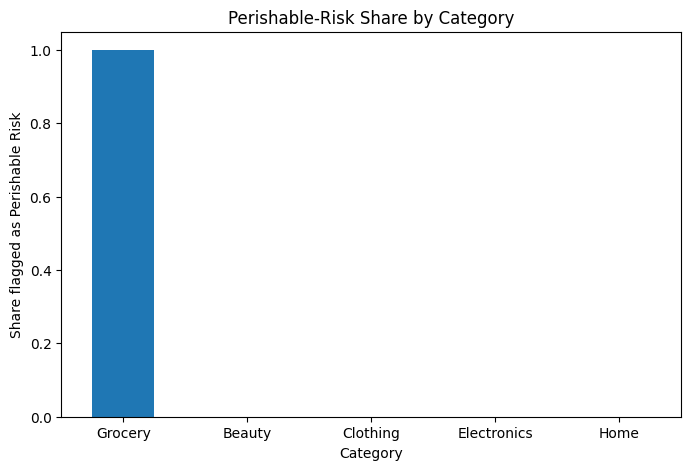

In [39]:

# ============================================================
# Perishable-risk proxy based on shelf life
# ============================================================

shelf_life_threshold = df["Shelf_Life_Days"].quantile(0.20)
df["Perishable_Risk_Flag"] = (df["Shelf_Life_Days"] <= shelf_life_threshold).astype(int)

print("20th percentile shelf life threshold:", shelf_life_threshold)

perishable_by_category = (
    df.groupby("Category")["Perishable_Risk_Flag"]
      .mean()
      .sort_values(ascending=False)
)

display(perishable_by_category.round(4))

plt.figure(figsize=(8, 5))
perishable_by_category.plot(kind="bar")
plt.title("Perishable-Risk Share by Category")
plt.ylabel("Share flagged as Perishable Risk")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.show()

### Interpretation

This analysis is especially important for categories such as **Grocery**.

Even if an item sells often, it may still deserve lower stocking priority if:
- shelf life is short
- storage space is costly
- replenishment risk is high

This is why a category-sensitive business framing is stronger than using raw demand alone.


## Model interpretability and business actionability

A strong model should do more than report accuracy.  
It should help answer business questions such as:

1. Which features push a product into **High** stocking priority?
2. Which categories are most often predicted as **High**?
3. Which specific products are the strongest candidates for aggressive stocking?
4. Which high-priority recommendations should be treated carefully because of **short shelf life**?

In the next sections, we interpret the best-performing classical model and use the model outputs to answer these questions with tables and visual summaries.



## Choose the best model and create a prediction dictionary

We first identify the best-performing model using **Weighted F1**, then collect the corresponding test predictions and probability scores.

This allows us to:
- create a confusion matrix
- inspect misclassifications
- rank items by predicted probability of belonging to the **High** class


In [40]:
# ============================================================
# Pick the best model using Weighted F1
# ============================================================

best_row = final_results.sort_values(["Weighted_F1", "Accuracy"], ascending=False).iloc[0]
best_model_name = best_row["Model"]
print("Best model selected from comparison table:", best_model_name)

# Prediction dictionary for convenience
prediction_dict = {
    "LogReg_TextOnly": {
        "pred": text_only_pred,
        "proba": text_only_clf.predict_proba(test_df["text_template"])
    },
    "LogReg_NumericOnly": {
        "pred": numeric_only_pred,
        "proba": numeric_only_clf.predict_proba(numeric_only_X_test)
    },
    "LogReg_Hybrid": {
        "pred": hybrid_pred,
        "proba": hybrid_clf.predict_proba(test_df[["text_template"] + numeric_feature_cols])
    },
    "CustomDL_Hybrid": {
        "pred": custom_pred,
        "proba": custom_pred_probs
    },
    "HF_DistilBERT_TextOnly": {
        "pred": hf_preds,
        "proba": softmax(hf_test_pred.predictions, axis=1)
    }
}

best_pred = prediction_dict[best_model_name]["pred"]
best_proba = prediction_dict[best_model_name]["proba"]

print("Prediction array shape:", np.shape(best_pred))
print("Probability matrix shape:", np.shape(best_proba))

Best model selected from comparison table: LogReg_Hybrid
Prediction array shape: (300,)
Probability matrix shape: (300, 3)



## Confusion matrix for the best model

A confusion matrix shows how well the best model separates the three classes:

- **Low**
- **Medium**
- **High**

For stocking decisions, this is important because confusing **High** with **Low** or **Medium** can lead to missed profit opportunities or overstocking risk.


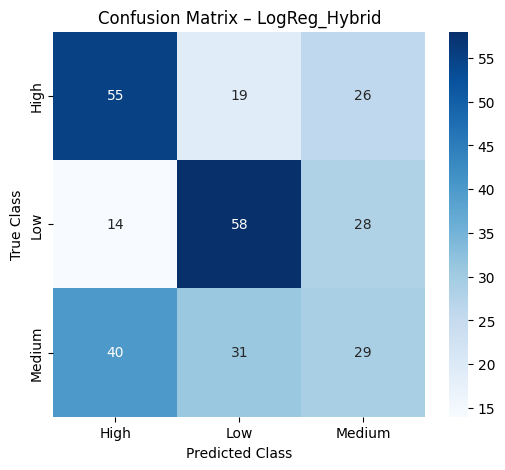

              precision    recall  f1-score   support

        High       0.50      0.55      0.53       100
         Low       0.54      0.58      0.56       100
      Medium       0.35      0.29      0.32       100

    accuracy                           0.47       300
   macro avg       0.46      0.47      0.47       300
weighted avg       0.46      0.47      0.47       300



In [41]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

cm = confusion_matrix(test_df["label_id"], best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Confusion Matrix – {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

print(classification_report(test_df["label_id"], best_pred, target_names=label_encoder.classes_))



## Why feature importance matters

Feature importance helps answer the question:

> **Why is the model predicting High stocking priority for some products and not others?**

For multiclass classification, we use two complementary views:

1. **Column-level permutation importance**  
   This tells us which original input columns matter most to the hybrid logistic model.

2. **Coefficient-based importance**  
   This tells us which engineered text/numeric features inside the logistic model push predictions toward a given class.

### Logistic regression formulation

For class \(k\), the score is:

$
z_k = \mathbf{w}_k^\top \mathbf{x} + b_k
$

and the probability is computed with the softmax function:

$
P(y=k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_j e^{z_j}}
$

A large positive coefficient means that the corresponding feature increases the probability of that class.


,Feature,Importance_Mean,Importance_STD
0,text_template,0.052597,0.012675
6,Base_Price,0.023723,0.011655
19,No_of_Customer_Purchases,0.017336,0.008313
7,Discount_Percentage,0.016000,0.015197
4,Is_Weekend,0.015079,0.008637
1,DayOfWeek,0.012984,0.007902
33,Avg_Basket_Size,0.011741,0.005554
9,Footfall_Index,0.011243,0.011659
20,Promotional_Campaign_Flag,0.010583,0.009271
14,Stock_On_Hand,0.010568,0.004311


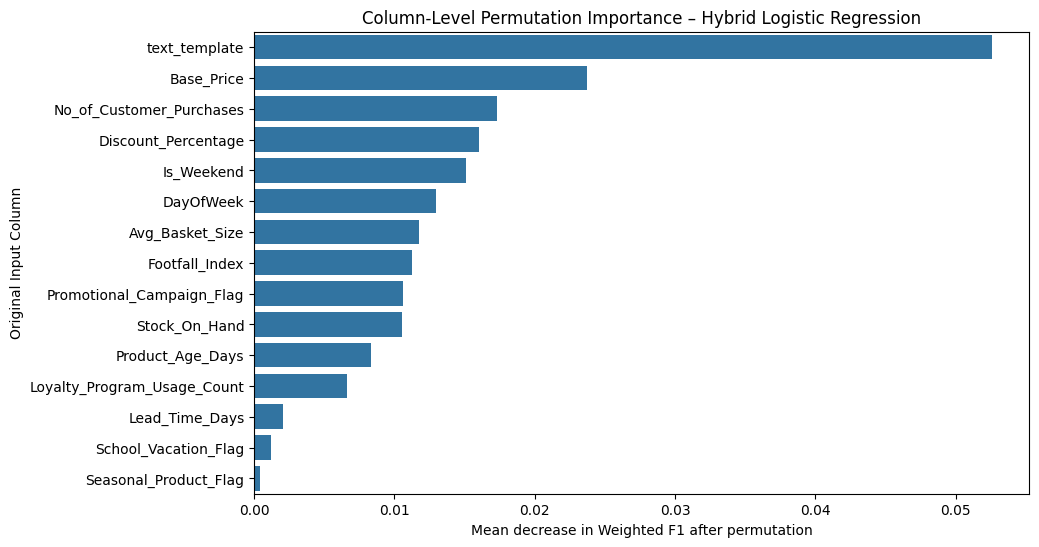

In [42]:

# ============================================================
# Column-level permutation importance for the hybrid logistic model
# ============================================================

from sklearn.inspection import permutation_importance

# Use a smaller sample for speed if needed
perm_sample = test_df[["text_template"] + numeric_feature_cols].copy()
perm_y = test_df["label_id"].copy()

perm_result = permutation_importance(
    hybrid_clf,
    perm_sample,
    perm_y,
    n_repeats=5,
    random_state=SEED,
    scoring="f1_weighted"
)

perm_importance_df = pd.DataFrame({
    "Feature": perm_sample.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
}).sort_values("Importance_Mean", ascending=False)

display(perm_importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=perm_importance_df.head(15), x="Importance_Mean", y="Feature")
plt.title("Column-Level Permutation Importance – Hybrid Logistic Regression")
plt.xlabel("Mean decrease in Weighted F1 after permutation")
plt.ylabel("Original Input Column")
plt.show()



### Interpretation of permutation importance

This table and chart show which original inputs matter most to the hybrid logistic classifier.

Typical interpretations are:

- If **text_template** ranks highly, product/category/brand/promotion semantics are informative.
- If columns such as **Current_Price**, **Shelf_Capacity**, or **Marketing_Spend** rank highly, then numeric business context is driving the stocking decision.
- If shelf-life or supply features rank highly, the model is learning operational risk rather than just sales potential.


,coef_High,coef_Low,coef_Medium,global_importance
text__bedding,0.825075,-0.595860,-0.229215,0.550050
text__tupperware,0.653405,-0.781975,0.128570,0.521316
text__sleepwell,0.743800,-0.629276,-0.114524,0.495867
text__computers 1011,-0.009855,0.717296,-0.707441,0.478197
text__category home,0.636674,-0.672966,0.036292,0.448644
text__home,0.636674,-0.672966,0.036292,0.448644
text__home product,0.636674,-0.672966,0.036292,0.448644
text__kitchenware,0.350777,-0.667042,0.316265,0.444695
text__amul,-0.656306,0.592676,0.063630,0.437538
text__computers 1010,0.043510,-0.623361,0.579851,0.415574


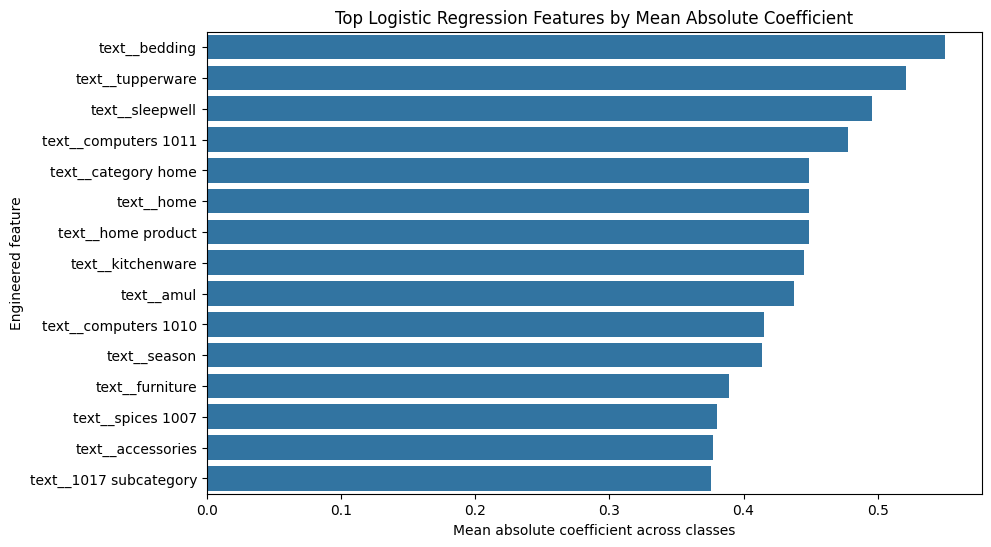

In [43]:

# ============================================================
# Feature-level coefficients from the hybrid logistic model
# ============================================================

hybrid_feature_names = hybrid_clf.named_steps["preprocessor"].get_feature_names_out()
hybrid_coef = hybrid_clf.named_steps["clf"].coef_

coef_df = pd.DataFrame(
    hybrid_coef.T,
    index=hybrid_feature_names,
    columns=[f"coef_{cls}" for cls in label_encoder.classes_]
)

# Global importance based on absolute coefficient magnitude across classes
coef_df["global_importance"] = coef_df.abs().mean(axis=1)
coef_global = coef_df.sort_values("global_importance", ascending=False)

display(coef_global.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_global.head(15).reset_index(),
    x="global_importance",
    y="index"
)
plt.title("Top Logistic Regression Features by Mean Absolute Coefficient")
plt.xlabel("Mean absolute coefficient across classes")
plt.ylabel("Engineered feature")
plt.show()



## Class-specific drivers

The next tables show which features most strongly push predictions toward each class:

- **Low**
- **Medium**
- **High**

Positive coefficients increase the odds of that class, while negative coefficients reduce them.



Top positive features for class: High


,coef_High
text__bedding,0.825075
text__sleepwell,0.743800
text__tupperware,0.653405
text__home,0.636674
text__home product,0.636674
text__category home,0.636674
text__furniture,0.583795
text__grains 1005,0.525202
text__1005 subcategory,0.497598
text__1005,0.497598


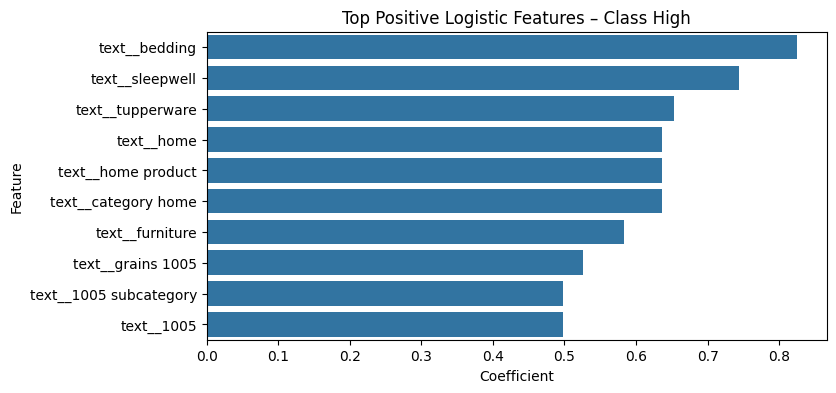


Top positive features for class: Low


,coef_Low
text__computers 1011,0.717296
text__season,0.620666
text__amul,0.592676
text__accessories,0.565980
text__gifting,0.563044
text__festivaltype gifting,0.563044
text__gifting season,0.563044
text__ashirvad,0.540917
text__spices,0.458550
text__zara,0.456097


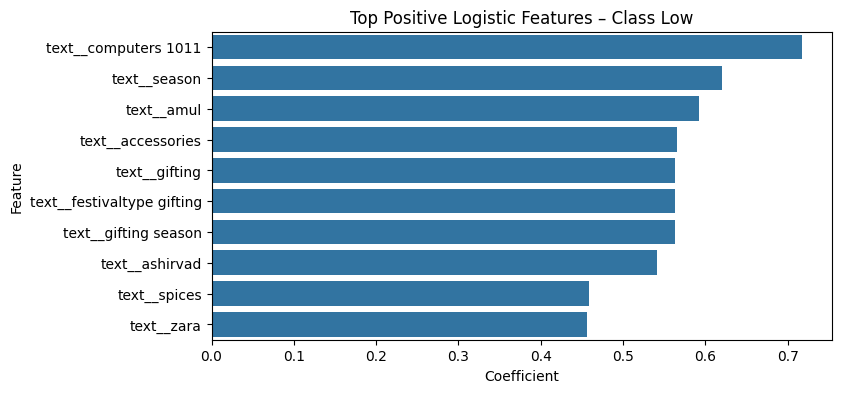


Top positive features for class: Medium


,coef_Medium
text__computers 1010,0.579851
text__spices 1007,0.569994
text__makeup 1017,0.513678
text__computers 1017,0.508837
text__1017,0.507556
text__1017 subcategory,0.507556
text__activewear 1000,0.483987
text__nivea fragrance,0.424523
text__haircare,0.412234
text__1010,0.371965


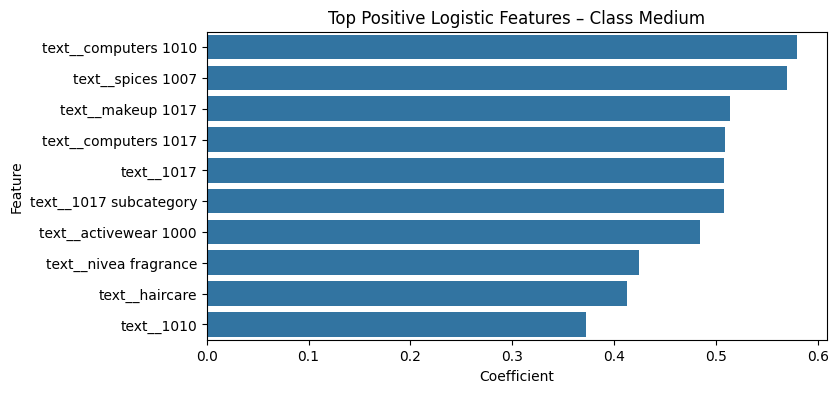

In [44]:

# ============================================================
# Top positive features for each class
# ============================================================

for cls in label_encoder.classes_:
    col = f"coef_{cls}"
    top_pos = coef_df[[col]].sort_values(col, ascending=False).head(10)
    print(f"\nTop positive features for class: {cls}")
    display(top_pos)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=top_pos.reset_index(), x=col, y="index")
    plt.title(f"Top Positive Logistic Features – Class {cls}")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.show()



## Score the full dataset with the best operationally useful model

Even if a deep model performs slightly better, the **hybrid logistic model** is especially useful because it is interpretable and supports business decision-making.

We score the full dataset with the hybrid logistic classifier and extract:

- predicted class
- predicted probability of **High** stocking priority
- risk-aware candidate recommendations


In [45]:

# ============================================================
# Score the full dataset with the hybrid logistic model
# ============================================================

full_hybrid_proba = hybrid_clf.predict_proba(df[["text_template"] + numeric_feature_cols])
full_hybrid_pred = hybrid_clf.predict(df[["text_template"] + numeric_feature_cols])

df_scored = df.copy()
df_scored["Predicted_Class_ID"] = full_hybrid_pred
df_scored["Predicted_Class"] = label_encoder.inverse_transform(full_hybrid_pred)

# Probability of the High class
high_class_index = list(label_encoder.classes_).index("High")
df_scored["Pred_Prob_High"] = full_hybrid_proba[:, high_class_index]

# Useful business quantities
df_scored["Unit_Margin"] = df_scored["Current_Price"] - df_scored["Unit_Cost"]
df_scored["Gross_Profit"] = df_scored["Unit_Margin"] * df_scored["Daily_Units_Sold"]
df_scored["Profit_per_Shelf_Unit"] = df_scored["Gross_Profit"] / (df_scored["Shelf_Capacity"] + 1e-6)

display(df_scored[[
    "Category", "Product_Name", "Predicted_Class", "Pred_Prob_High",
    "Current_Price", "Unit_Cost", "Shelf_Capacity", "Shelf_Life_Days"
]].head())


,Category,Product_Name,Predicted_Class,Pred_Prob_High,Current_Price,Unit_Cost,Shelf_Capacity,Shelf_Life_Days
0,Grocery,Nestle Beverages 1002,Low,0.171764,405.99,322.20,30,54
1,Home,Tupperware Decor 1014,Medium,0.426315,62.99,47.96,99,2244
2,Electronics,Sony Computers 1015,High,0.395176,348.20,319.44,71,1196
3,Grocery,Nestle Spices 1012,Low,0.071569,198.34,266.76,28,7
4,Grocery,Tata Spices 1016,Medium,0.306492,240.94,172.32,95,10



## Which categories appear most often in the predicted High class?

This answers an operational question:

> **According to the model, which categories deserve the strongest stocking priority?**


Predicted High class counts by category


,count
Category,
Home,286
Clothing,166
Electronics,101
Beauty,75
Grocery,44


Predicted High class share by category


,proportion
Category,
Home,0.4256
Clothing,0.2470
Electronics,0.1503
Beauty,0.1116
Grocery,0.0655


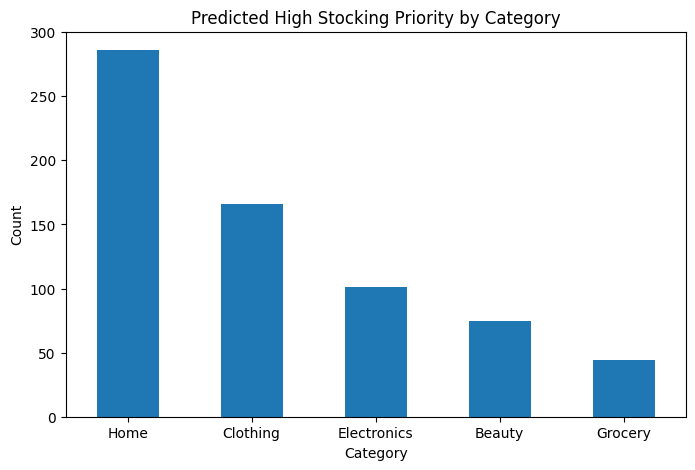

In [46]:

pred_high_df = df_scored[df_scored["Predicted_Class"] == "High"]

pred_high_counts = pred_high_df["Category"].value_counts()
pred_high_share = pred_high_df["Category"].value_counts(normalize=True)

print("Predicted High class counts by category")
display(pred_high_counts)

print("Predicted High class share by category")
display(pred_high_share.round(4))

plt.figure(figsize=(8, 5))
pred_high_counts.plot(kind="bar")
plt.title("Predicted High Stocking Priority by Category")
plt.ylabel("Count")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.show()



## Which products are the strongest candidates for stocking?

To make the model actionable, we rank products by:

- probability of **High** stocking priority
- profit per shelf unit

This helps identify products that are both likely to deserve high priority and economically efficient to stock.


In [47]:

product_recommendation_table = (
    df_scored.groupby(["Category", "Product_Name"], as_index=False)
    .agg(
        Mean_Prob_High=("Pred_Prob_High", "mean"),
        Avg_Profit_per_Shelf_Unit=("Profit_per_Shelf_Unit", "mean"),
        Avg_Shelf_Life_Days=("Shelf_Life_Days", "mean"),
        Avg_Daily_Units_Sold=("Daily_Units_Sold", "mean"),
        Avg_Current_Price=("Current_Price", "mean")
    )
    .sort_values(["Mean_Prob_High", "Avg_Profit_per_Shelf_Unit"], ascending=False)
)

display(product_recommendation_table.head(20))


,Category,Product_Name,Mean_Prob_High,Avg_Profit_per_Shelf_Unit,Avg_Shelf_Life_Days,Avg_Daily_Units_Sold,Avg_Current_Price
80,Home,Ikea Bedding 1008,0.743402,51.706449,2326.0,105.818182,191.633636
93,Home,Tupperware Bedding 1001,0.740037,53.273189,2790.0,109.000000,209.768571
90,Home,Sleepwell Furniture 1013,0.727130,8.842461,2850.0,103.421053,212.829474
92,Home,Sleepwell Kitchenware 1015,0.712899,22.536020,2782.0,111.315789,203.924737
81,Home,Ikea Furniture 1018,0.695415,59.867347,2770.0,112.625000,204.466875
95,Home,Tupperware Bedding 1017,0.683555,-3.549796,2810.0,129.263158,137.031053
89,Home,Sleepwell Furniture 1000,0.656805,27.496808,1117.0,118.090909,158.713636
91,Home,Sleepwell Kitchenware 1009,0.608802,21.229837,1569.0,116.400000,164.066500
94,Home,Tupperware Bedding 1006,0.593157,18.324140,2358.0,99.133333,223.159333
96,Home,Tupperware Decor 1003,0.584611,16.205558,2178.0,112.473684,178.396316



## Shelf-life-aware caution analysis

A product may have strong sales or profit potential but still be risky to stock aggressively if its shelf life is short.

To make this visible, we flag short-shelf-life items and compare them against model recommendations.


Products predicted as High priority but with short shelf life


,Category,Product_Name,Pred_Prob_High,Shelf_Life_Days,Profit_per_Shelf_Unit,Current_Price,Shelf_Capacity
49,Grocery,Amul Dairy 1010,0.782361,31,23.962222,32.32,72
1375,Grocery,Ashirvad Grains 1005,0.724979,18,9.740171,50.48,117
1107,Grocery,Ashirvad Grains 1005,0.682421,18,19.781470,47.16,34
987,Grocery,Ashirvad Grains 1005,0.668930,18,62.559999,82.31,72
258,Grocery,Nestle Dairy 1003,0.663275,48,260.501987,160.95,20
490,Grocery,Ashirvad Grains 1005,0.650114,18,182.089994,219.21,29
1011,Grocery,Amul Dairy 1010,0.645734,31,10.963636,24.03,44
1753,Grocery,Nestle Dairy 1003,0.598456,48,-17.894615,86.79,52
1008,Grocery,Ashirvad Grains 1005,0.580338,18,50.903999,157.85,95
906,Grocery,Nestle Beverages 1002,0.564105,54,46.124999,45.02,64


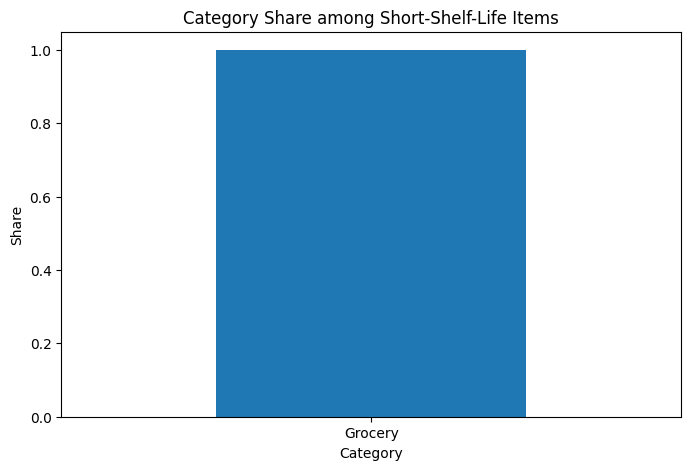

In [48]:

# Define short shelf life as the bottom 20% of the distribution
short_life_threshold = df_scored["Shelf_Life_Days"].quantile(0.20)
df_scored["Short_Shelf_Life_Flag"] = (df_scored["Shelf_Life_Days"] <= short_life_threshold).astype(int)

high_but_risky = (
    df_scored[(df_scored["Predicted_Class"] == "High") & (df_scored["Short_Shelf_Life_Flag"] == 1)]
    [["Category", "Product_Name", "Pred_Prob_High", "Shelf_Life_Days",
      "Profit_per_Shelf_Unit", "Current_Price", "Shelf_Capacity"]]
    .sort_values(["Pred_Prob_High", "Profit_per_Shelf_Unit"], ascending=False)
)

print("Products predicted as High priority but with short shelf life")
display(high_but_risky.head(20))

risky_category_share = (
    df_scored[df_scored["Short_Shelf_Life_Flag"] == 1]["Category"]
    .value_counts(normalize=True)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
risky_category_share.plot(kind="bar")
plt.title("Category Share among Short-Shelf-Life Items")
plt.ylabel("Share")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.show()



## Business interpretation of the best model

The best model is useful only if it supports clear actions.

With the scored dataset, we can now answer questions such as:

1. **Which categories most often receive High stocking priority?**
2. **Which specific products have the strongest High-priority probability?**
3. **Which recommendations look attractive on profit density?**
4. **Which high-priority candidates should be reviewed because of short shelf life?**

This is how the model moves from a generic classifier to a decision-support tool.



## Suggested use of the model in practice

A retailer can use the scored output in several ways:

- **Inventory planning:** rank products by predicted High-priority probability
- **Shelf allocation:** prioritize products with high profit per shelf unit
- **Risk review:** flag predicted High items with short shelf life
- **Category strategy:** compare how often categories fall into the High class
- **Promotion planning:** inspect which promotion/product combinations shift items into High priority

This turns the model into a practical stocking recommendation engine rather than a purely academic classifier.


# Final Conclusion

This notebook reframed the retail task from pure demand forecasting to **category-aware stocking priority classification**.

## What was done

1. Created a business-driven target:
   - `Low`
   - `Medium`
   - `High`

2. Built a **column-aware text template** to represent product/category/brand/promotion information

3. Compared:
   - text-only logistic regression
   - numeric-only logistic regression
   - hybrid logistic regression
   - custom deep learning hybrid model
   - Hugging Face text classifier

4. Performed business analysis on:
   - which categories dominate the High class
   - shelf-life risk by category
   - top products under the priority score

## Main takeaway

For this business framing, the best stocking decisions are not determined only by sales volume. They also depend on:
- margin
- shelf space efficiency
- shelf life
- supply reliability
- customer and promotional context

This is much closer to how real retail inventory decisions are made.

## Resources

- Original dataset: [https://www.kaggle.com/datasets/samyukthas/master-retail-dataset](https://www.kaggle.com/datasets/samyukthas/master-retail-dataset)
- Hugging Face Transformers library: [https://huggingface.co/docs/transformers/](https://huggingface.co/docs/transformers/)
- TensorFlow Keras documentation: [https://www.tensorflow.org/guide/keras](https://www.tensorflow.org/guide/keras)

## Model Performance Summary

The comparison of the three model families (Logistic Regression, Custom Deep Learning, and Hugging Face Transformer) revealed the following:

- The **Hybrid Logistic Regression** model achieved the best performance with a Weighted F1 score of 0.4670 and an Accuracy of 0.4733, highlighting the importance of combining both textual and numerical features.
- The **Custom Deep Learning Hybrid** model followed closely with a Weighted F1 score of 0.4589 and an Accuracy of 0.4833, indicating the potential for deep learning to capture complex interactions.
- The **Hugging Face DistilBERT (Text-Only)** model, while powerful for text, showed a Weighted F1 of 0.4098 and Accuracy of 0.4333, suggesting that text alone was less effective than hybrid approaches for this specific problem.
- The **Numeric-Only Logistic Regression** performed similarly to the Text-Only variant, with a Weighted F1 of 0.4116 and Accuracy of 0.4267.
- The **Text-Only Logistic Regression** had a Weighted F1 of 0.4285 and Accuracy of 0.4367.

Overall, hybrid approaches that leverage both structured numeric data and rich text features provided the most robust classification of stocking priority.